In [1]:
from pathlib import Path
import numpy as np
import json

In [2]:
import json
import numpy as np
from pathlib import Path


def get_detail_result(path):

    result_dir = Path(path)
    json_files = sorted(result_dir.glob("*.json"))

    cohorts = [
        "all",
        "stable",
        "converter",
        "forward_converter",
        "reverse_converter",
        "mixed_converter",
    ]

    time_names = [
        "current",
        "6_month",
        "12_month",
        "24_month",
    ]

    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]

    class_names = [
        "CN",
        "MCI",
        "AD",
    ]

    # =========================================================
    # Initialize results
    # =========================================================

    results = {}

    for cohort in cohorts:

        results[cohort] = {

            # -------------------------------------------------
            # Overall classification metrics
            # -------------------------------------------------
            "overall": {
                metric: []
                for metric in metric_names
            },

            # -------------------------------------------------
            # Overall per-class metrics
            # -------------------------------------------------
            "overall_per_class": {
                class_name: {
                    metric: []
                    for metric in [
                        "precision",
                        "recall",
                        "f1",
                    ]
                }
                for class_name in class_names
            },

            # -------------------------------------------------
            # By timepoint
            # -------------------------------------------------
            "by_time": {
                time: {

                    "metrics": {
                        metric: []
                        for metric in metric_names
                    },

                    "per_class": {
                        class_name: {
                            metric: []
                            for metric in [
                                "precision",
                                "recall",
                                "f1",
                            ]
                        }
                        for class_name in class_names
                    },

                }
                for time in time_names
            },

            # -------------------------------------------------
            # Sequence
            # -------------------------------------------------
            "sequence": {
                "subject_count": [],
                "exact_sequence_accuracy": [],
                "mean_timepoints_correct": [],
            },

            # -------------------------------------------------
            # Transitions
            # -------------------------------------------------
            "transitions": {
                "transition_count": [],
                "changed_transition_count": [],
                "exact_delta_accuracy": [],
                "direction_accuracy": [],
                "transition_mae": [],
                "changed_transition_accuracy": [],
                "changed_transition_direction_accuracy": [],
            },
        }

    # =========================================================
    # Read JSON files
    # =========================================================

    for json_file in json_files:

        with open(json_file, "r") as f:
            data = json.load(f)

        for cohort in cohorts:

            cohort_data = data[cohort]

            # =================================================
            # Overall
            # =================================================

            overall = cohort_data["overall"]

            for metric in metric_names:

                results[cohort]["overall"][metric].append(
                    overall[metric]
                )

            # -------------------------------------------------
            # Overall per-class
            # -------------------------------------------------

            for class_name in class_names:

                per_class = overall["per_class"][class_name]

                for metric in [
                    "precision",
                    "recall",
                    "f1",
                ]:

                    results[cohort][
                        "overall_per_class"
                    ][class_name][metric].append(
                        per_class[metric]
                    )

            # =================================================
            # By timepoint
            # =================================================

            for time in time_names:

                time_data = cohort_data[
                    "by_time"
                ][time]

                # ---------------------------------------------
                # Classification metrics
                # ---------------------------------------------

                for metric in metric_names:

                    results[cohort][
                        "by_time"
                    ][time]["metrics"][metric].append(
                        time_data[metric]
                    )

                # ---------------------------------------------
                # Per-class metrics
                # ---------------------------------------------

                for class_name in class_names:

                    per_class = time_data[
                        "per_class"
                    ][class_name]

                    for metric in [
                        "precision",
                        "recall",
                        "f1",
                    ]:

                        results[cohort][
                            "by_time"
                        ][time][
                            "per_class"
                        ][class_name][metric].append(
                            per_class[metric]
                        )

            # =================================================
            # Sequence
            # =================================================

            sequence = cohort_data["sequence"]

            for metric in [
                "subject_count",
                "exact_sequence_accuracy",
                "mean_timepoints_correct",
            ]:

                results[cohort][
                    "sequence"
                ][metric].append(
                    sequence[metric]
                )

            # =================================================
            # Transitions
            # =================================================

            transitions = cohort_data[
                "transitions"
            ]

            for metric in [
                "exact_delta_accuracy",
                "direction_accuracy",
                "transition_mae",
                "changed_transition_accuracy",
                "changed_transition_direction_accuracy",
            ]:

                results[cohort][
                    "transitions"
                ][metric].append(
                    transitions[metric]
                )

    return results


In [3]:
def calculate_mean_sd(results):

    summary = {}

    for cohort, cohort_data in results.items():

        summary[cohort] = {

            # =================================================
            # Overall
            # =================================================
            "overall": {},

            "overall_per_class": {},

            # =================================================
            # By time
            # =================================================
            "by_time": {},

            # =================================================
            # Sequence
            # =================================================
            "sequence": {},

            # =================================================
            # Transitions
            # =================================================
            "transitions": {},
        }

        # =====================================================
        # Overall
        # =====================================================

        for metric, values in (
            cohort_data["overall"].items()
        ):

            values = np.asarray(
                values,
                dtype=float,
            )

            summary[cohort][
                "overall"
            ][metric] = {
                "mean": np.nanmean(values),
                "sd": np.nanstd(
                    values,
                    ddof=1,
                ),
                "mean_sd": (
                    f"{np.nanmean(values):.4f} ± "
                    f"{np.nanstd(values, ddof=1):.4f}"
                ),
            }

        # =====================================================
        # Overall per-class
        # =====================================================

        for class_name, class_data in (
            cohort_data[
                "overall_per_class"
            ].items()
        ):

            summary[cohort][
                "overall_per_class"
            ][class_name] = {}

            for metric, values in class_data.items():

                values = np.asarray(
                    values,
                    dtype=float,
                )

                summary[cohort][
                    "overall_per_class"
                ][class_name][metric] = {
                    "mean": np.nanmean(values),
                    "sd": np.nanstd(
                        values,
                        ddof=1,
                    ),
                    "mean_sd": (
                        f"{np.nanmean(values):.4f} ± "
                        f"{np.nanstd(values, ddof=1):.4f}"
                    ),
                }

        # =====================================================
        # By time
        # =====================================================

        for time, time_data in (
            cohort_data["by_time"].items()
        ):

            summary[cohort][
                "by_time"
            ][time] = {
                "metrics": {},
                "per_class": {},
            }

            # -------------------------------------------------
            # Metrics
            # -------------------------------------------------

            for metric, values in (
                time_data["metrics"].items()
            ):

                values = np.asarray(
                    values,
                    dtype=float,
                )

                summary[cohort][
                    "by_time"
                ][time][
                    "metrics"
                ][metric] = {
                    "mean": np.nanmean(values),
                    "sd": np.nanstd(
                        values,
                        ddof=1,
                    ),
                    "mean_sd": (
                        f"{np.nanmean(values):.4f} ± "
                        f"{np.nanstd(values, ddof=1):.4f}"
                    ),
                }

            # -------------------------------------------------
            # Per-class
            # -------------------------------------------------

            for class_name, class_data in (
                time_data["per_class"].items()
            ):

                summary[cohort][
                    "by_time"
                ][time][
                    "per_class"
                ][class_name] = {}

                for metric, values in class_data.items():

                    values = np.asarray(
                        values,
                        dtype=float,
                    )

                    summary[cohort][
                        "by_time"
                    ][time][
                        "per_class"
                    ][class_name][metric] = {
                        "mean": np.nanmean(values),
                        "sd": np.nanstd(
                            values,
                            ddof=1,
                        ),
                        "mean_sd": (
                            f"{np.nanmean(values):.4f} ± "
                            f"{np.nanstd(values, ddof=1):.4f}"
                        ),
                    }

        # =====================================================
        # Sequence
        # =====================================================

        for metric, values in (
            cohort_data["sequence"].items()
        ):

            values = np.asarray(
                values,
                dtype=float,
            )

            summary[cohort][
                "sequence"
            ][metric] = {
                "mean": np.nanmean(values),
                "sd": np.nanstd(
                    values,
                    ddof=1,
                ),
                "mean_sd": (
                    f"{np.nanmean(values):.4f} ± "
                    f"{np.nanstd(values, ddof=1):.4f}"
                ),
            }

        # =====================================================
        # Transitions
        # =====================================================

        for metric, values in (
            cohort_data["transitions"].items()
        ):

            values = np.asarray(
                values,
                dtype=float,
            )

            summary[cohort][
                "transitions"
            ][metric] = {
                "mean": np.nanmean(values),
                "sd": np.nanstd(
                    values,
                    ddof=1,
                ),
                "mean_sd": (
                    f"{np.nanmean(values):.4f} ± "
                    f"{np.nanstd(values, ddof=1):.4f}"
                ),
            }

    return summary


In [4]:
results = get_detail_result("../results/cv/proposed_with_mean_standarization")
summary = calculate_mean_sd(results)

/tmp/ipykernel_29362/42693464.py:218: RuntimeWarning: Mean of empty slice
  "mean": np.nanmean(values),
/root/data/github/AD_progression_visualization/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_29362/42693464.py:224: RuntimeWarning: Mean of empty slice
  f"{np.nanmean(values):.4f} ± "
/tmp/ipykernel_29362/42693464.py:164: RuntimeWarning: Mean of empty slice
  "mean": np.nanmean(values),
/tmp/ipykernel_29362/42693464.py:170: RuntimeWarning: Mean of empty slice
  f"{np.nanmean(values):.4f} ± "


In [5]:

with open("../results/proposed_cv_summary_mean_standarization_all_modaity.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4,  ensure_ascii=False,)

In [49]:
import json

with open("../results/proposed_cv_summary_mean_standarization_all_modaity.json", "r", encoding="utf-8") as f:
    summary = json.load(f,)

In [50]:
import pandas as pd

rows = []

for cohort, cohort_data in summary.items():

    rows.append({
        "cohort": cohort,
        "class": "overall",
        "precision": cohort_data["overall"]["macro_precision"]["mean_sd"],
        "recall": cohort_data["overall"]["macro_recall"]["mean_sd"],
        "f1": cohort_data["overall"]["macro_f1"]["mean_sd"],
    })

    for class_name, class_data in cohort_data["overall_per_class"].items():

        rows.append({
            "cohort": cohort,
            "class": class_name,
            "precision": class_data["precision"]["mean_sd"],
            "recall": class_data["recall"]["mean_sd"],
            "f1": class_data["f1"]["mean_sd"],
        })

df = pd.DataFrame(rows)

print(df)


               cohort    class        precision           recall  \
0                 all  overall  0.8531 ± 0.0188  0.8576 ± 0.0183   
1                 all       CN  0.8551 ± 0.0486  0.8976 ± 0.0608   
2                 all      MCI  0.7853 ± 0.0236  0.7778 ± 0.0404   
3                 all       AD  0.9189 ± 0.0176  0.8975 ± 0.0280   
4              stable  overall  0.8670 ± 0.0208  0.8714 ± 0.0196   
5              stable       CN  0.8683 ± 0.0470  0.9157 ± 0.0550   
6              stable      MCI  0.7955 ± 0.0256  0.7851 ± 0.0438   
7              stable       AD  0.9373 ± 0.0188  0.9133 ± 0.0293   
8           converter  overall  0.7144 ± 0.0292  0.7054 ± 0.0553   
9           converter       CN  0.6285 ± 0.0903  0.6028 ± 0.1652   
10          converter      MCI  0.7466 ± 0.0544  0.7474 ± 0.0452   
11          converter       AD  0.7680 ± 0.0304  0.7661 ± 0.0716   
12  forward_converter  overall  0.7425 ± 0.0492  0.7847 ± 0.0778   
13  forward_converter       CN  0.6662 ± 0.1390 

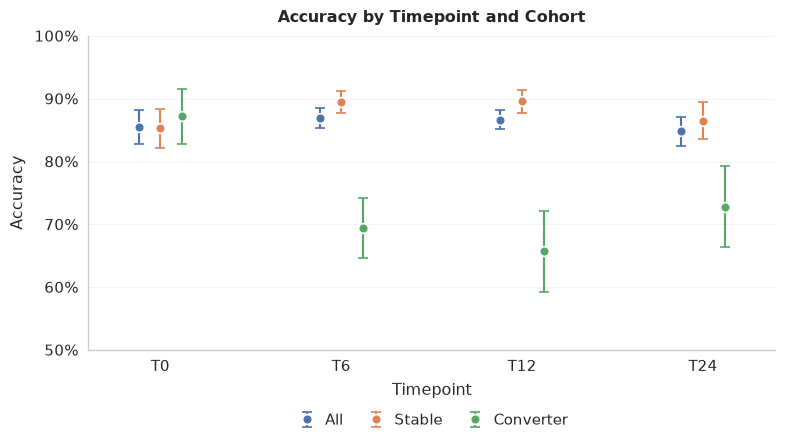

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# ============================================================
# Publication style
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2,
)

plt.rcParams.update({
    "font.family": "sans-serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
})

# ============================================================
# Settings
# ============================================================

cohorts = ["all", "stable", "converter"]

cohort_labels = {
    "all": "All",
    "stable": "Stable",
    "converter": "Converter",
}

time_names = [
    "current",
    "6_month",
    "12_month",
    "24_month",
]

time_labels = ["T0", "T6", "T12", "T24"]

# ============================================================
# Colors
# ============================================================

palette = sns.color_palette()

colors = {
    "all": palette[0],
    "stable": palette[1],
    "converter": palette[2],
}

# Small offsets separate cohorts at each timepoint
offsets = {
    "all": -0.12,
    "stable": 0.00,
    "converter": 0.12,
}

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(time_names))

# ============================================================
# Plot mean accuracy +/- SD
# ============================================================

for cohort in cohorts:

    means = np.array([
        summary[cohort]["by_time"][time]["metrics"]
        ["accuracy"]["mean"]
        for time in time_names
    ], dtype=float)

    sds = np.array([
        summary[cohort]["by_time"][time]["metrics"]
        ["accuracy"]["sd"]
        for time in time_names
    ], dtype=float)

    ax.errorbar(
        x + offsets[cohort],
        means,
        yerr=sds,

        fmt="o",
        linestyle="none",

        color=colors[cohort],
        ecolor=colors[cohort],

        markersize=7,
        markerfacecolor=colors[cohort],
        markeredgecolor="white",
        markeredgewidth=1.2,

        elinewidth=1.5,
        capsize=3.5,
        capthick=1.3,

        label=cohort_labels[cohort],
        zorder=3,
    )

# ============================================================
# Titles and axis labels
# ============================================================

ax.set_title(
    "Accuracy by Timepoint and Cohort",
    pad=10,
    fontweight="bold",
)

ax.set_xlabel("Timepoint", labelpad=6)
ax.set_ylabel("Accuracy", labelpad=6)

# ============================================================
# X axis
# ============================================================

ax.set_xticks(x)
ax.set_xticklabels(time_labels)
ax.set_xlim(-0.4, len(time_names) - 0.6)

# ============================================================
# Y axis
# ============================================================

ax.set_ylim(0.50, 1.00)
ax.set_yticks(np.arange(0.50, 1.01, 0.10))

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0, decimals=0)
)

# ============================================================
# Grid and spines
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ============================================================
# Ticks
# ============================================================

ax.tick_params(
    axis="both",
    which="major",
    length=3,
    width=0.7,
    pad=4,
)

# ============================================================
# Legend
# ============================================================

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False,
    handletextpad=0.5,
    columnspacing=1.5,
    handlelength=1.5,
)

# ============================================================
# Layout
# ============================================================

fig.tight_layout(rect=[0, 0.06, 1, 1])

# ============================================================
# Save
# ============================================================

plt.savefig(
    "../results/accuracy_by_time_cohort.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    "../results/accuracy_by_time_cohort.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [53]:
import json

with open("../results/ensembled_ensemble_proposed_with_mean_standarization/result_test_set_ensemble.json", "r", encoding="utf-8") as f:
    ensemble_result = json.load(f,)

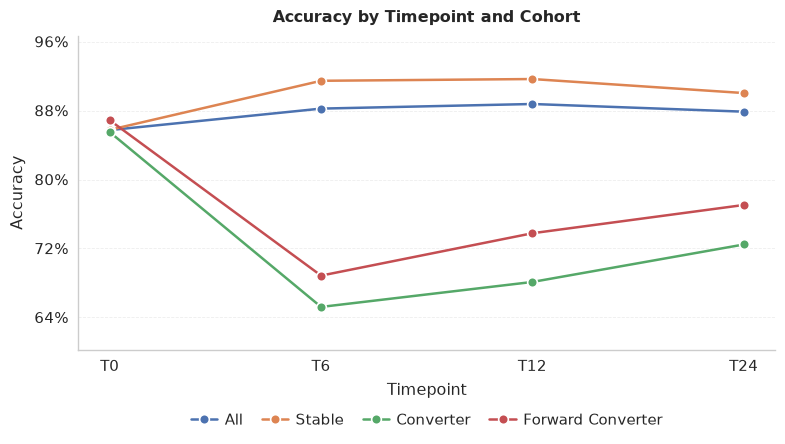

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, MaxNLocator

# ============================================================
# Publication style — consistent with previous figures
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2,
)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# Settings
# ============================================================

cohorts = [
    "all",
    "stable",
    "converter",
    "forward_converter",
]

cohort_labels = {
    "all": "All",
    "stable": "Stable",
    "converter": "Converter",
    "forward_converter": "Forward Converter",
}

time_names = [
    "current",
    "6_month",
    "12_month",
    "24_month",
]

time_labels = ["T0", "T6", "T12", "T24"]

# ============================================================
# Colors — consistent Seaborn palette
# ============================================================

palette = sns.color_palette()

colors = {
    "all": palette[0],
    "stable": palette[1],
    "converter": palette[2],
    "forward_converter": palette[3],
}

# ============================================================
# Collect accuracy values
# ============================================================

accuracy = {}

for cohort in cohorts:
    accuracy[cohort] = np.array([
        ensemble_result[cohort]["by_time"][time]["accuracy"]
        for time in time_names
    ], dtype=float)

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(time_names))

# ============================================================
# Plot accuracy curves
# ============================================================

for cohort in cohorts:
    ax.plot(
        x,
        accuracy[cohort],
        color=colors[cohort],
        linewidth=1.8,
        marker="o",
        markersize=7,
        markerfacecolor=colors[cohort],
        markeredgecolor="white",
        markeredgewidth=1.2,
        label=cohort_labels[cohort],
        zorder=3,
    )

# ============================================================
# Titles and axis labels
# ============================================================

ax.set_title(
    "Accuracy by Timepoint and Cohort",
    pad=10,
    fontweight="bold",
)

ax.set_xlabel("Timepoint", labelpad=6)
ax.set_ylabel("Accuracy", labelpad=6)

# ============================================================
# X axis
# ============================================================

ax.set_xticks(x)
ax.set_xticklabels(time_labels)
ax.set_xlim(-0.15, len(time_names) - 0.85)

# ============================================================
# Y axis — percentage formatting and sensible limits
# ============================================================

all_values = np.concatenate(list(accuracy.values()))
valid_values = all_values[np.isfinite(all_values)]

if len(valid_values) > 0:
    y_min = max(0.0, valid_values.min() - 0.05)
    y_max = min(1.0, valid_values.max() + 0.05)

    # Avoid a collapsed axis if all values are identical
    if y_max - y_min < 0.10:
        midpoint = (y_min + y_max) / 2
        y_min = max(0.0, midpoint - 0.05)
        y_max = min(1.0, midpoint + 0.05)

    ax.set_ylim(y_min, y_max)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0, decimals=0)
)

ax.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

# ============================================================
# Grid and spines
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ============================================================
# Ticks
# ============================================================

ax.tick_params(
    axis="both",
    which="major",
    length=3,
    width=0.7,
    pad=4,
)

# ============================================================
# Legend
# ============================================================

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=4,
    frameon=False,
    handletextpad=0.5,
    columnspacing=1.3,
    handlelength=1.8,
)

# ============================================================
# Layout
# ============================================================

fig.tight_layout(rect=[0, 0.06, 1, 1])

# ============================================================
# Save
# ============================================================

plt.savefig(
    "../results/ensembled_accuracy_by_time_cohort.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    "../results/ensembled_accuracy_by_time_cohort.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

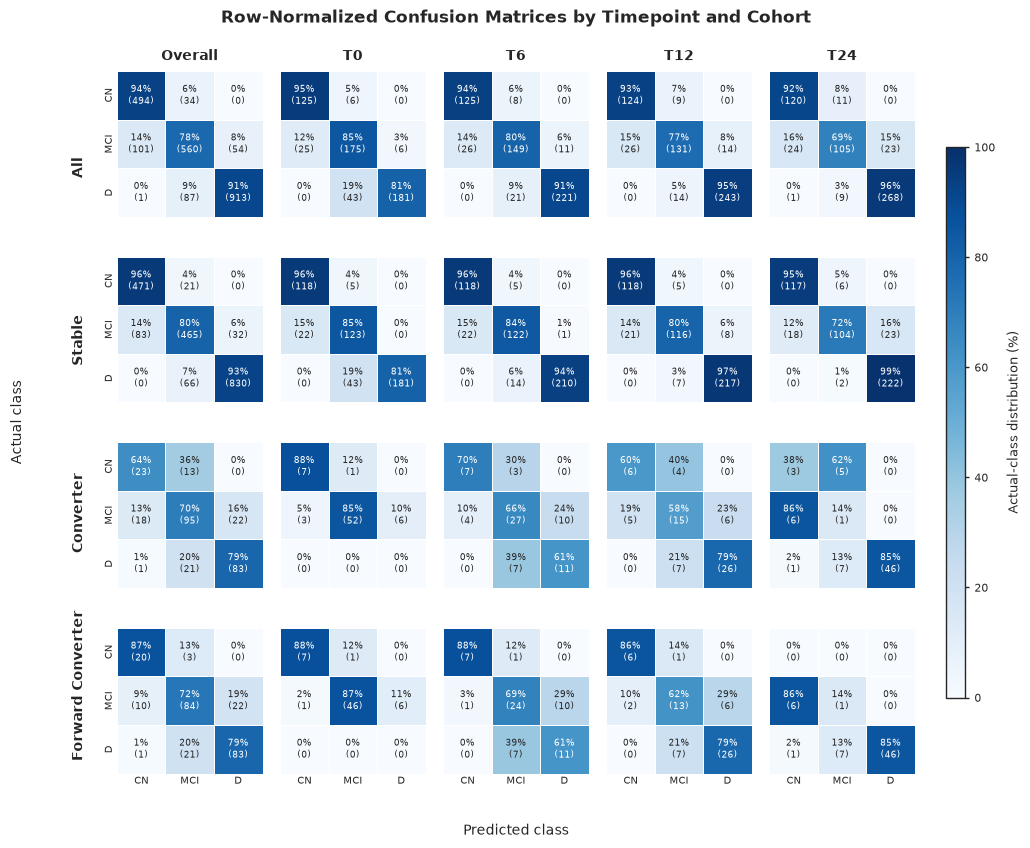

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Publication style
# ============================================================

sns.set_theme(
    style="white",
    context="paper",
)


# ============================================================
# Settings
# ============================================================

cohorts = [
    "all",
    "stable",
    "converter",
    "forward_converter",
]

cohort_labels = {
    "all": "All",
    "stable": "Stable",
    "converter": "Converter",
    "forward_converter": "Forward Converter",
}

time_names = [
    "overall",
    "current",
    "6_month",
    "12_month",
    "24_month",
]

time_labels = [
    "Overall",
    "T0",
    "T6",
    "T12",
    "T24",
]

class_labels = [
    "CN",
    "MCI",
    "D",
]


# ============================================================
# Collect confusion matrices
# ============================================================

confusion_matrices = {}

for cohort in cohorts:

    confusion_matrices[cohort] = {}

    confusion_matrices[cohort]["overall"] = np.asarray(
        ensemble_result[cohort]
        ["overall"]
        ["confusion_matrix"],
        dtype=float,
    )

    for time in time_names[1:]:

        confusion_matrices[cohort][time] = np.asarray(
            ensemble_result[cohort]
            ["by_time"]
            [time]
            ["confusion_matrix"],
            dtype=float,
        )


# ============================================================
# Row-normalize
#
# Each row = one actual class.
# Each row therefore sums to 100%.
# ============================================================

normalized_matrices = {}

for cohort in cohorts:

    normalized_matrices[cohort] = {}

    for time in time_names:

        matrix = confusion_matrices[cohort][time]

        row_sums = matrix.sum(
            axis=1,
            keepdims=True,
        )

        normalized_matrix = np.divide(
            matrix,
            row_sums,
            out=np.zeros_like(matrix, dtype=float),
            where=row_sums != 0,
        )

        normalized_matrices[cohort][time] = (
            normalized_matrix * 100
        )


# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=len(cohorts),
    ncols=len(time_names),
    figsize=(10.5, 8.6),
)


# ============================================================
# Plot heatmaps
# ============================================================

for row, cohort in enumerate(cohorts):

    for col, time in enumerate(time_names):

        ax = axes[row, col]

        # Raw counts
        count_matrix = confusion_matrices[cohort][time]

        # Row-normalized percentages
        percent_matrix = normalized_matrices[cohort][time]

        # ----------------------------------------------------
        # Create percentage + count annotations
        # ----------------------------------------------------

        annotations = np.empty(
            percent_matrix.shape,
            dtype=object,
        )

        for i in range(percent_matrix.shape[0]):

            for j in range(percent_matrix.shape[1]):

                percentage = percent_matrix[i, j]
                count = count_matrix[i, j]

                annotations[i, j] = (
                    f"{percentage:.0f}%\n"
                    f"({count:.0f})"
                )

        # ----------------------------------------------------
        # Heatmap
        # ----------------------------------------------------

        sns.heatmap(
            percent_matrix,

            ax=ax,

            cmap="Blues",

            # Fixed 0–100% scale for every panel
            vmin=0,
            vmax=100,

            annot=annotations,
            fmt="",

            annot_kws={
                "fontsize": 6.5,
                "ha": "center",
                "va": "center",
            },

            linewidths=0.7,
            linecolor="white",

            square=True,

            xticklabels=class_labels,
            yticklabels=class_labels,

            # One shared colorbar
            cbar=False,
        )

        # ----------------------------------------------------
        # Column titles
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
                time_labels[col],
                fontsize=10,
                fontweight="bold",
                pad=8,
            )

        # ----------------------------------------------------
        # Axis labels
        # ----------------------------------------------------

        ax.set_xlabel("")
        ax.set_ylabel("")

        # ----------------------------------------------------
        # Y-axis labels
        # ----------------------------------------------------

        if col != 0:

            ax.set_yticklabels([])

        # ----------------------------------------------------
        # X-axis labels
        # ----------------------------------------------------

        if row != len(cohorts) - 1:

            ax.set_xticklabels([])

        # ----------------------------------------------------
        # Tick styling
        # ----------------------------------------------------

        ax.tick_params(
            axis="both",
            which="major",
            length=0,
            pad=2,
            labelsize=7,
        )


# ============================================================
# Cohort labels
# ============================================================

for row, cohort in enumerate(cohorts):

    pos = axes[row, 0].get_position()

    fig.text(
        pos.x0 - 0.035,
        (pos.y0 + pos.y1) / 2,

        cohort_labels[cohort],

        ha="right",
        va="center",

        fontsize=10,
        fontweight="bold",

        rotation=90,
    )


# ============================================================
# Global axis labels
# ============================================================

fig.text(
    0.50,
    0.025,

    "Predicted class",

    ha="center",
    va="center",

    fontsize=10,
)

fig.text(
    0.025,
    0.50,

    "Actual class",

    ha="center",
    va="center",

    rotation=90,

    fontsize=10,
)


# ============================================================
# Shared colorbar
# ============================================================

cbar_ax = fig.add_axes([
    0.91,
    0.18,
    0.018,
    0.64,
])

sm = plt.cm.ScalarMappable(
    cmap="Blues",
    norm=plt.Normalize(
        vmin=0,
        vmax=100,
    ),
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
)

cbar.set_label(
    "Actual-class distribution (%)",
    fontsize=9,
    labelpad=8,
)

cbar.set_ticks([
    0,
    20,
    40,
    60,
    80,
    100,
])

cbar.ax.tick_params(
    labelsize=8,
    length=3,
)


# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    "Row-Normalized Confusion Matrices by Timepoint and Cohort",
    fontsize=12,
    fontweight="bold",
    y=0.98,
)


# ============================================================
# Layout
# ============================================================

fig.subplots_adjust(
    left=0.12,
    right=0.88,
    top=0.91,
    bottom=0.09,

    wspace=0.12,
    hspace=0.25,
)


# ============================================================
# Save high-resolution PNG
# ============================================================

plt.savefig(
    "../results/"
    "confusion_matrices_row_normalized.png",

    dpi=600,

    bbox_inches="tight",

    facecolor="white",
)


# ============================================================
# Save vector PDF
# ============================================================

plt.savefig(
    "../results/"
    "confusion_matrices_row_normalized.pdf",

    bbox_inches="tight",

    facecolor="white",
)


# ============================================================
# Display
# ============================================================

plt.show()


In [56]:
import json


model_details = []
for index in range(10):
    with open(f"../results/ensembled_ensemble_proposed_with_mean_standarization/model_details_test_set_{index}.json", mode='r') as f:
        model_detail = json.load(f)
        model_details.append(model_detail)

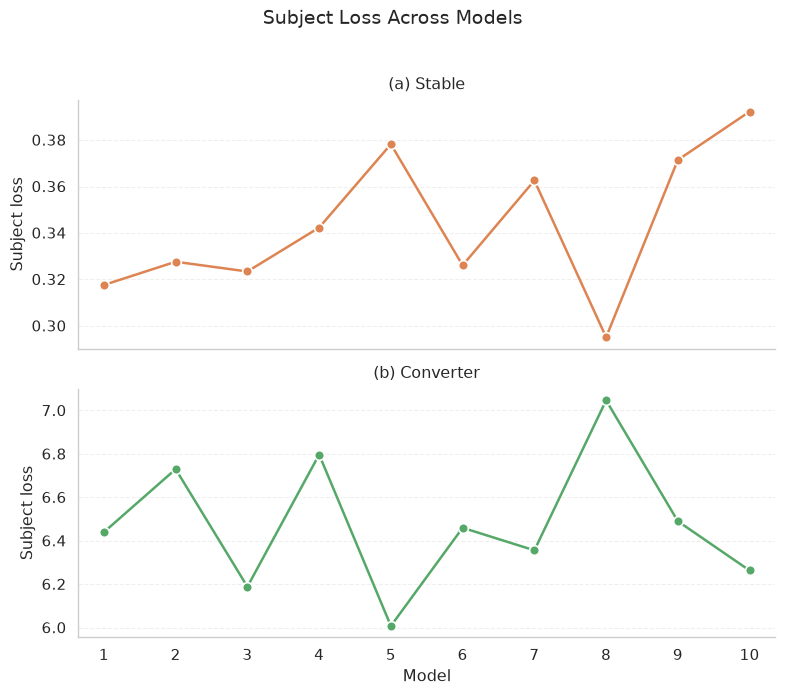

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2,
)

# ============================================================
# Prepare data
# ============================================================

rows = []

for model_idx, model in enumerate(model_details[:10]):
    rows.append({
        "model": model_idx + 1,
        "Stable": model["subject_loss_stable"],
        "Converter": model["subject_loss_converter"],
    })

df = pd.DataFrame(rows)

# ============================================================
# Plot: 2 rows x 1 column
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 7),
    sharex=True,
)

palette = sns.color_palette()

colors = {
    "Stable": palette[1],
    "Converter": palette[2],
}

plot_configs = [
    {
        "ax": axes[0],
        "column": "Stable",
        "title": "(a) Stable",
    },
    {
        "ax": axes[1],
        "column": "Converter",
        "title": "(b) Converter",
    },
]

# ============================================================
# Plot each group
# ============================================================

for config in plot_configs:
    ax = config["ax"]
    column = config["column"]

    ax.plot(
        df["model"],
        df[column],
        color=colors[column],
        marker="o",
        markersize=7,
        markerfacecolor=colors[column],
        markeredgecolor="white",
        markeredgewidth=1.2,
        linewidth=1.8,
        zorder=3,
    )

    ax.set_title(config["title"], loc="center", pad=8)
    ax.set_ylabel("Subject loss")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
    )
    ax.grid(axis="x", visible=False)

    ax.margins(x=0.04)

# ============================================================
# Shared formatting
# ============================================================

axes[0].tick_params(axis="x", labelbottom=False)

axes[1].set_xlabel("Model")
axes[1].set_xticks(df["model"])

fig.suptitle(
    "Subject Loss Across Models",
    y=0.99,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# ============================================================
# Save
# ============================================================

plt.savefig(
    "subject_loss_2x1.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "subject_loss_2x1.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

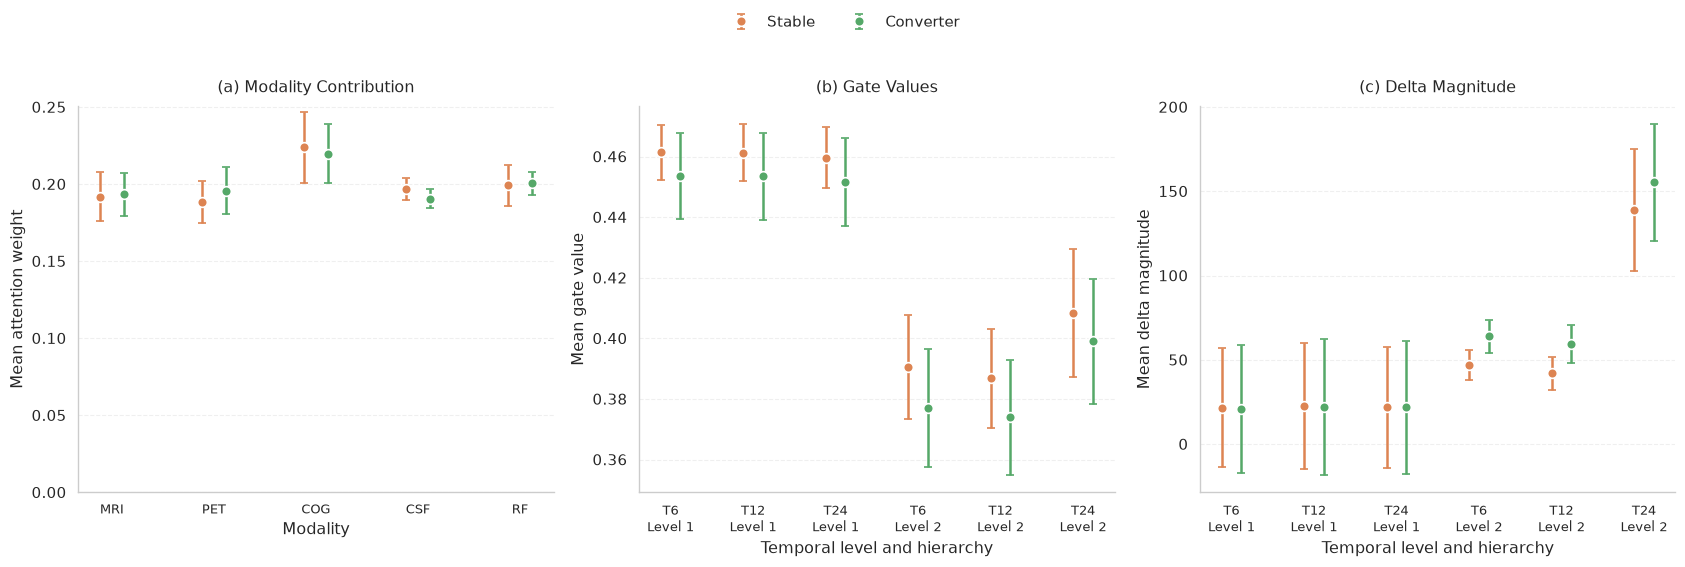

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

modalities = ["MRI", "PET", "COG", "CSF", "RF"]

gate_names = [
    "T6\nLevel 1",
    "T12\nLevel 1",
    "T24\nLevel 1",
    "T6\nLevel 2",
    "T12\nLevel 2",
    "T24\nLevel 2",
]

delta_names = gate_names.copy()

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2,
)

palette = sns.color_palette()

colors = {
    "Stable": palette[1],
    "Converter": palette[2],
}

offsets = {
    "Stable": -0.12,
    "Converter": 0.12,
}

# ============================================================
# Helper function: mean and 95% CI
# ============================================================

def calculate_summary(df, group_col, value_col, type_col):
    summary = (
        df.groupby([group_col, type_col])[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    summary["ci95"] = (
        1.96 * summary["std"] / np.sqrt(summary["count"])
    )

    return summary


# ============================================================
# 1. Modality contribution
# ============================================================

rows = []

for model_idx, model in enumerate(model_details):
    stable = [x[0] for x in model["attention_weights_stable"]]
    converter = [x[0] for x in model["attention_weights_converter"]]

    for modality, stable_weight, converter_weight in zip(
        modalities, stable, converter
    ):
        rows.append({
            "model": model_idx,
            "modality": modality,
            "Stable": stable_weight,
            "Converter": converter_weight,
        })

df_modality = pd.DataFrame(rows)

df_modality_long = df_modality.melt(
    id_vars=["model", "modality"],
    value_vars=["Stable", "Converter"],
    var_name="type",
    value_name="value",
)

summary_modality = calculate_summary(
    df_modality_long, "modality", "value", "type"
)


# ============================================================
# 2. Gate values
# ============================================================

rows = []

for model_idx, model in enumerate(model_details[:10]):
    stable = model["gate_stable"]
    converter = model["gate_converter"]

    for idx, gate in enumerate(gate_names):
        rows.append({
            "model": model_idx + 1,
            "gate": gate,
            "Stable": np.mean(stable[idx]),
            "Converter": np.mean(converter[idx]),
        })

df_gate = pd.DataFrame(rows)

df_gate_long = df_gate.melt(
    id_vars=["model", "gate"],
    value_vars=["Stable", "Converter"],
    var_name="type",
    value_name="value",
)

summary_gate = calculate_summary(
    df_gate_long, "gate", "value", "type"
)


# ============================================================
# 3. Delta magnitude
# ============================================================

rows = []

for model_idx, model in enumerate(model_details[:10]):
    stable = model["delta_magnitude_stable"]
    converter = model["delta_magnitude_converter"]

    for idx, delta in enumerate(delta_names):
        rows.append({
            "model": model_idx + 1,
            "delta": delta,
            "Stable": np.mean(stable[idx]),
            "Converter": np.mean(converter[idx]),
        })

df_delta = pd.DataFrame(rows)

df_delta_long = df_delta.melt(
    id_vars=["model", "delta"],
    value_vars=["Stable", "Converter"],
    var_name="type",
    value_name="value",
)

summary_delta = calculate_summary(
    df_delta_long, "delta", "value", "type"
)


# ============================================================
# Plot all three as subplots
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(17, 5.5),
)

plot_configs = [
    {
        "ax": axes[0],
        "summary": summary_modality,
        "categories": modalities,
        "group_col": "modality",
        "xlabel": "Modality",
        "ylabel": "Mean attention weight",
        "title": "(a) Modality Contribution",
        "legend_loc": "upper right",
    },
    {
        "ax": axes[1],
        "summary": summary_gate,
        "categories": gate_names,
        "group_col": "gate",
        "xlabel": "Temporal level and hierarchy",
        "ylabel": "Mean gate value",
        "title": "(b) Gate Values",
        "legend_loc": "upper right",
    },
    {
        "ax": axes[2],
        "summary": summary_delta,
        "categories": delta_names,
        "group_col": "delta",
        "xlabel": "Temporal level and hierarchy",
        "ylabel": "Mean delta magnitude",
        "title": "(c) Delta Magnitude",
        "legend_loc": "upper left",
    },
]

for config in plot_configs:
    ax = config["ax"]
    summary = config["summary"]
    categories = config["categories"]
    group_col = config["group_col"]

    for attention_type in ["Stable", "Converter"]:
        data = (
            summary[summary["type"] == attention_type]
            .set_index(group_col)
            .reindex(categories)
            .reset_index()
        )

        x = (
            np.arange(len(categories))
            + offsets[attention_type]
        )

        ax.errorbar(
            x,
            data["mean"],
            yerr=data["ci95"],
            fmt="o",
            markersize=7,
            markerfacecolor=colors[attention_type],
            markeredgecolor="white",
            markeredgewidth=1.2,
            ecolor=colors[attention_type],
            elinewidth=1.8,
            capsize=3,
            capthick=1.3,
            label=attention_type,
            zorder=3,
        )

    ax.set_xticks(np.arange(len(categories)))
    ax.set_xticklabels(categories)

    ax.set_xlabel(config["xlabel"])
    ax.set_ylabel(config["ylabel"])
    ax.set_title(config["title"], pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
    )
    ax.grid(axis="x", visible=False)

    ax.tick_params(axis="x", labelsize=9)

    if config["group_col"] == "modality":
        ax.set_ylim(bottom=0)

# ============================================================
# One shared legend
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
)

# ============================================================
# Layout and save
# ============================================================

fig.tight_layout(rect=[0, 0, 1, 0.93])

fig.savefig(
    "combined_analysis.pdf",
    bbox_inches="tight",
)

fig.savefig(
    "combined_analysis.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()